In [175]:
import torch
from savanna.model.backbone import BackbonePipe
from savanna.arguments.global_config import *
from savanna.arguments import GlobalConfig
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### V0.1

In [177]:
model_cfg = {
  #  "pipe_parallel_size": 1,
  #  "model_parallel_size": 1,

   ############### model settings
   "num_layers": 28,
   "hidden_size": 2048,
   "operator_config": [[["hyena"], 28]],
   "short_conv_L": 3,
   "postnorm": True,
   "use_hyena_filter": True,
  #  "hyena_filter_cls": "modal",
  #  "hyena_filter_r_min": 0.5,
  #  "hyena_filter_r_max": 0.999,
   "use_fast_heads": False,
   "seq_length": 8096,
   "norm": "layernorm",
   "output_layer_parallelism": "column",
   "identity_mlp": False,
   "prenorm": True,
  #  "no_weight_tying": true,
  #  "gpt_j_residual": true,
   "pos_emb": None,
   "num_heads": 512, # hidden-size / num_heads unique filters
   "num_attention_heads": 512, # nb: this is only used for mpu with vanilla Hyena, no heads to split


   ############## misc optims
   "scaled_upper_triang_masked_softmax_fusion": False,
   "bias_gelu_fusion": False,

   ############### init
   "init_method": "small_init",
   "output_layer_init_method": "wang_init",

   ############## optimizer
   "optimizer": {
     "type": "Adam",
     "params": {
       "lr": 0.0006,
       "betas": [0.9, 0.95],
       "eps": 1.0e-8,
     }
   },
   "min_lr": 0.00006,

   ############### sys optims
   "zero_optimization": {
    "stage": 0,
    "allgather_partitions": True,
    "allgather_bucket_size": 500000000,
    "overlap_comm": True,
    "reduce_scatter": True,
    "reduce_bucket_size": 500000000,
    "contiguous_gradients": True,
  },

   ################# batch sizes
   "train_micro_batch_size_per_gpu": 64,
   "data_impl": "mmap",

   ################# act checkpointing
   "checkpoint_activations": True,
   "checkpoint_num_layers": 1,
   "partition_activations": True,
   "synchronize_each_layer": True,

   ################# regularization
   "gradient_clipping": 1.0,
   "weight_decay": 0.1,
   "hidden_dropout": 0.0,
   "attention_dropout": 0.0,

   ################ precision
   "precision": "bfloat16",
   "bf16": {
   "enabled": True
    },
   
   ################# training
   "train_iters": 71500,
   "lr_decay_iters": 71500,
   "distributed_backend": "nccl",
   "lr_decay_style": "cosine",
   "warmup": 0.01,
   "checkpoint_factor": 10000,
   "eval_interval": 10000,
   "eval_iters": 10,

   ################ logging
   "log_interval": 200,
   "steps_per_print": 200,
   "keep_last_n_checkpoints": 4,
   "wall_clock_breakdown": False,
}

args = GlobalConfig(**model_cfg)
args.use_mup=False
args.mup_init_scale=0
args.padded_vocab_size=50304
args.hidden_dropout=0.0
args.operator_config=["hyena" for _ in range(args.num_layers)]
args.checkpoint_activations=False
args.pipe_parallel_size=0
args.pipe_partition_method="type:transformer|mlp"
args.pipe_num_stages=1
args.mup_embedding_mult=0
args.mup_rp_embedding_mult=0
args.lazy_mpu_init=False
args.rank=0
args.model_parallel_size=1

In [178]:
from savanna.initialize import initialize_megatron
import deepspeed
import os 
os.environ['RANK'] = '0'
os.environ['WORLD_SIZE'] = '1'
deepspeed.init_distributed(dist_backend='nccl')
initialize_megatron(args)

model = BackbonePipe(args, num_tokentypes=0, parallel_output=True).to_sequential()
# 


torch distributed is already initialized, skipping initialization ...
_initialize_distributed() model parallel is already initialized
> setting random seeds to 1234 ...
[2023-06-29 18:43:37,280] [INFO] [checkpointing.py:226:model_parallel_cuda_manual_seed] > initializing model parallel cuda seeds on global rank 0, model parallel rank 0, and data parallel rank 0 with model parallel seed: 3952 and data parallel seed: 1234
SEED_LAYERS=False BASE_SEED=1234 SEED_FN=None
Using topology: {ProcessCoord(pipe=0, data=0): 0}
[2023-06-29 18:43:37,283] [INFO] [module.py:358:_partition_layers] Partitioning pipeline stages with method type:transformer|mlp
stage=0 layers=33
     0: EmbeddingPipe
     1: _pre_transformer_block
     2: ParallelBlockPipe
     3: ParallelBlockPipe
     4: ParallelBlockPipe
     5: ParallelBlockPipe
     6: ParallelBlockPipe
     7: ParallelBlockPipe
     8: ParallelBlockPipe
     9: ParallelBlockPipe
    10: ParallelBlockPipe
    11: ParallelBlockPipe
    12: ParallelBloc

In [179]:
for layer_idx in range(len(model.sequential)):
    print('loading layer...', layer_idx)
    try:
        ckpt = torch.load(f"/var/cr01_data/mpoli/code/safari-neox/configs/checkpoints/hyena1.5b_4m/30000/layer_{layer_idx:02d}-model_00-model_states.pt")
        model.sequential[layer_idx].load_state_dict(ckpt)
        print('loaded layer', layer_idx)
    except:
        pass

loading layer... 0
loaded layer 0
loading layer... 1
loading layer... 2
loaded layer 2
loading layer... 3
loaded layer 3
loading layer... 4
loaded layer 4
loading layer... 5
loaded layer 5
loading layer... 6
loaded layer 6
loading layer... 7
loaded layer 7
loading layer... 8
loaded layer 8
loading layer... 9
loaded layer 9
loading layer... 10
loaded layer 10
loading layer... 11
loaded layer 11
loading layer... 12
loaded layer 12
loading layer... 13
loaded layer 13
loading layer... 14
loaded layer 14
loading layer... 15
loaded layer 15
loading layer... 16
loaded layer 16
loading layer... 17
loaded layer 17
loading layer... 18
loaded layer 18
loading layer... 19
loaded layer 19
loading layer... 20
loaded layer 20
loading layer... 21
loaded layer 21
loading layer... 22
loaded layer 22
loading layer... 23
loaded layer 23
loading layer... 24
loaded layer 24
loading layer... 25
loaded layer 25
loading layer... 26
loaded layer 26
loading layer... 27
loaded layer 27
loading layer... 28
loaded 

### Checking causality

In [165]:
u = torch.randn(12)
u1 = torch.fft.irfft(torch.fft.rfft(u, n=24), n=24)[:12]
u2 = torch.fft.irfft(torch.fft.rfft(u[:6], n=12), n=12)[:6]
u1, u2

(tensor([ 0.5386, -0.3538,  0.7199, -0.6203, -0.6113, -0.7991, -1.5284, -0.5742,
          0.3856, -0.1862, -0.0886, -0.4559]),
 tensor([ 0.5386, -0.3538,  0.7199, -0.6203, -0.6113, -0.7991]))

In [173]:
y1[0,0,:,1], y2[0,0,:,1]

(tensor([ 0.0208, -0.1038, -0.1701,  0.5388, -0.1568, -0.4206,  0.7580, -0.5370,
         -0.1586,  2.4410], device='cuda:0', grad_fn=<SelectBackward0>),
 tensor([ 0.0208, -0.1038, -0.1701,  0.5388, -0.1568, -0.4206,  0.7580, -0.5370,
         -0.1586,  2.4410,  2.9337], device='cuda:0', grad_fn=<SelectBackward0>))

In [169]:
sq = 128
b = 1
np = 1
hn = 4

query = torch.randn(sq, b, np, hn).cuda()
key = torch.randn(sq, b, np, hn).cuda()
value = torch.randn(sq, b, np, hn).cuda()
query, key, value = query.requires_grad_(), key.requires_grad_(), value.requires_grad_()

mixer = model.sequential[2].attention.mixer.to('cuda')
y1 = mixer(query[:10], key[:10], value[:10])
y2 = mixer(query[:11], key[:11], value[:11])
y1, y2

pre conv z tensor([-0.0452,  0.2344,  0.9390, -1.4156,  0.3072,  0.0144, -0.7457,  0.1631,
        -0.1617, -0.1074], device='cuda:0', grad_fn=<SliceBackward0>)
Pre conv tensor([-0.8176+0.0000j,  0.5678+0.9198j,  1.0251-0.3652j,  0.4652-0.6983j,
         0.2573-0.8986j, -0.0929-1.3938j, -1.8765-1.6076j, -2.9396+1.2956j,
         0.0743+2.9662j,  1.7734+0.9995j,  1.4046+0.0000j], device='cuda:0',
       grad_fn=<SliceBackward0>) tensor([-0.0221+0.0000j, -0.0387-0.0239j, -0.0845+0.0536j,  0.0523+0.0536j,
        -0.0306-0.0431j, -0.0146+0.0427j, -0.0433-0.0224j, -0.0248+0.1233j,
         0.1108-0.0122j, -0.0310-0.0367j,  0.0039+0.0000j], device='cuda:0',
       grad_fn=<SliceBackward0>)
In conv
torch.Size([1, 4, 10]) torch.Size([4]) tensor([ 0.0103, -0.0299, -0.3358, -0.1481,  0.6753, -0.5033,  0.1662,  1.6464,
        -1.2085,  1.0101], device='cuda:0', grad_fn=<SliceBackward0>)
Post conv tensor([ 0.0103, -0.0299, -0.3358, -0.1481,  0.6753, -0.5033,  0.1662,  1.6464,
        -1.2085,  1

(tensor([[[[-0.0135,  0.0208,  0.3943, -0.0211],
           [ 0.0184, -0.1038,  0.3937, -0.0834],
           [ 0.1064, -0.1701, -0.0049,  0.0478],
           [ 0.1294,  0.5388,  0.0456,  0.4962],
           [ 0.7914, -0.1568,  0.9325, -0.0213],
           [-0.1181, -0.4206,  0.4184,  0.3207],
           [-0.1568,  0.7580, -2.8578,  1.6508],
           [-2.1388, -0.5370, -0.1633,  1.5612],
           [-1.2952, -0.1586,  1.1731, -2.3746],
           [ 0.9542,  2.4410,  0.1895, -2.9254]]]], device='cuda:0',
        grad_fn=<ReshapeAliasBackward0>),
 tensor([[[[-0.0135,  0.0208,  0.3943, -0.0211],
           [ 0.0184, -0.1038,  0.3937, -0.0834],
           [ 0.1064, -0.1701, -0.0049,  0.0478],
           [ 0.1294,  0.5388,  0.0456,  0.4962],
           [ 0.7914, -0.1568,  0.9325, -0.0213],
           [-0.1181, -0.4206,  0.4184,  0.3207],
           [-0.1568,  0.7580, -2.8578,  1.6508],
           [-2.1388, -0.5370, -0.1633,  1.5612],
           [-1.2952, -0.1586,  1.1731, -2.3746],
       

In [134]:
y1[0,0,:,0], y2[0,0,:,0]

(tensor([ 0.4308,  0.8408,  0.0332,  0.2204, -0.3697,  0.0125,  0.2438,  0.1710,
         -0.1174,  1.6417], device='cuda:0', grad_fn=<SelectBackward0>),
 tensor([ 0.3936,  0.6608, -0.0149,  0.3335, -0.4271,  0.0169,  0.3161,  0.1619,
         -0.1163,  1.6361,  2.7193], device='cuda:0', grad_fn=<SelectBackward0>))

## Hyena filters

In [100]:
import matplotlib.pyplot as plt

mixers = []
for layer_idx in range(args.num_layers):
    if hasattr(model.sequential[layer_idx], 'attention'):
        mixers.append(model.sequential[layer_idx].attention.mixer)

In [101]:
filter = mixers[-1].filter(8096)
fig = plt.figure(figsize=(20,10))
for z in range(12):
    plt.plot(filter[z,1000:4000].detach().cpu().numpy(),alpha=1)


In [102]:
fig, axs = plt.subplots(7, 4, figsize=(20, 20))

for i in range(4):
    for j in range(7):
        filter = mixers[4*i+j].filter(8096)
        for z in range(128):
            axs[j, i].plot(filter[z].detach().cpu().numpy())
            axs[j, i].set_title(f'layer {4*i+j}')

In [114]:
for k in range(33): plt.plot(mixers[0].filter.pos_emb.z[0,:,k].detach().cpu())

In [ ]:
[{'context': 'hello world', 'text': '\n\nI am trying to create a simple hello world program in C. I am using the following code:\n#include <stdio.h>\n#include <stdlib.h>\n#include <string.h>\n\nint main(int argc, char *argv[])\n', 'length': 64, 'finished': False, 'message': None, 'duration_seconds': 20.132519721984863}]

In [13]:
model = model.to('cuda:0').to(torch.bfloat16).eval()
u = torch.tensor([0, 1, 128, 256, 0, 1, 128])[None].long().to(model.sequential[2].attention.mixer.filter.pos_emb.z.device)
position_ids = torch.ones_like(u).to(model.sequential[2].attention.mixer.filter.pos_emb.z.device)
attention_mask = torch.ones_like(u).to(model.sequential[2].attention.mixer.filter.pos_emb.z.device)


In [14]:
#   "vocab-file": "/var/cr01_data/mpoli_data/mpoli_data/gpt2-vocab.json",
#   "merge-file": "/var/cr01_data/mpoli_data/mpoli_data/gpt2-merges.txt",
from savanna.tokenizer.gpt2_tokenization import GPT2Tokenizer
tokenizer = GPT2Tokenizer(vocab_file="/var/cr01_data/mpoli_data/mpoli_data/gpt2-vocab.json", merges_file="/var/cr01_data/mpoli_data/mpoli_data/gpt2-merges.txt")

In [15]:
import torch.nn.functional as F
test = "Hello, World!"
test = tokenizer.tokenize(test)
tokens = tokenizer.convert_tokens_to_ids(test)
test = torch.tensor(tokens)[None].long().to(model.sequential[2].attention.mixer.filter.pos_emb.z.device)
#test = F.pad(test, (0, 8096 - test.shape[1]))

In [16]:
y = model((test, position_ids, attention_mask))
print(tokenizer.decode(y[0][:].argmax(dim=-1).tolist()))

hashasyx pain


In [143]:
test

tensor([[15496,  2159]], device='cuda:0')

In [138]:
u = torch.tensor([0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0])[None].long().to(model.sequential[2].attention.mixer.filter.pos_emb.z.device)
y = model((u, position_ids, attention_mask))

In [139]:
y.argmax(-1)

tensor([[11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11,
         11, 11, 11]], device='cuda:0')

In [115]:
model

SequentialWrapper(
  (sequential): Sequential(
    (0): EmbeddingPipe(
      (word_embeddings): VocabParallelEmbedding()
      (embedding_dropout): Dropout(p=0.0, inplace=False)
    )
    (1): Lambda()
    (2): ParallelBlockPipe(
      (input_layernorm): LayerNorm((2048,), eps=1e-05, elementwise_affine=True)
      (post_attention_layernorm): LayerNorm((2048,), eps=1e-05, elementwise_affine=True)
      (attention): ParallelSequenceMixer(
        (dense_projection): ColumnParallelLinear()
        (hyena_proj_conv): Conv1d(6144, 6144, kernel_size=(3,), stride=(1,), padding=(2,), groups=6144)
        (mixer): ParallelHyenaOperator(
          (act): Identity()
          (filter): ParallelImplicitFreeformFilter(
            (act): Sin()
            (pos_emb): PositionalEmbedding()
            (implicit_filter): Sequential(
              (0): Linear(in_features=33, out_features=64, bias=True)
              (1): Sin()
              (2): Linear(in_features=64, out_features=64, bias=True)
      

### V0.2

In [67]:
model_cfg = {
  #  "pipe_parallel_size": 1,
  #  "model_parallel_size": 1,

   ############### model settings
   "num_layers": 28,
   "hidden_size": 2048,
   "operator_config": [[["hyena"], 28]],
   "short_conv_L": 3, 
   # reasonable values seem to be 2-3-4. Not too many parameters are here, however
   
   "prenorm": True, # always on 
   
   "postnorm": False,
    # unclear if it should be on, should turn off when `identity_mlp` is True. 
    # LLaMA needs both pre and post norms to be stable
    # Hyena with gated MLP (LLaMA-style) appears to converge better without postnorm but is unstable,
    # when adding postnorm the performance is worse than Hyena with regular MLP?

   "log_attn_norms": False,

   "hyena_filter_fast_decay": 0.9,
   "hyena_filter_slow_decay": 1.5,
   # percentage of sequence length at which the Hyena filters decay to approximately 0

   "hyena_filter_w": 1, 
   # we used to keep this higher, but found minimal difference. May want to run quick ablations with w=1, w=10

   "hyena_filter_order": 1536,
   # the larger, the better. Parameter cost is marginal

   "use_fast_heads": False,
   # always false

   "use_slow_heads": True,
   # our *best* multihead version. Does not increase parameters, makes model stronger (and lowers throughput)
   # could benefit from a custom kernel.

   "use_hyena_filter": True,
   "seq_length": 8192,  
   "norm": "rmsnorm", 
   # Did not notice significant differences between layernorm and rmsnorm

   "rms_norm_epsilon": 1.0e-6,
   "output_layer_parallelism": "column",
   "identity_mlp": False,
  # use this to turn off post Hyena / Attention MLP

  #  "no_weight_tying": true,
  #  "gpt_j_residual": true,
  "pos_emb": None,
  "num_heads": 512,
   # with heads active: number of heads. Select so that model width is 4 or 8 times larger, 
   # since heads will perform outer products of dim `model_width / num_heads`. Any larger multiple 
   # may result in significantly higher memory consumption
  "num_attention_heads": 512, 
  # keep this same as the above

  "mlp_type": "regular",
  # "mlp_type": "llama", improves performance but makes model unstable, suggesting we may need to tweak
  # the layer for stability
  #"activation": "softsign",

   ############## misc optims
   "scaled_upper_triang_masked_softmax_fusion": False,
   "bias_gelu_fusion": False,

   ############### init
   "init_method": "small_init",
   "output_layer_init_method": "wang_init",

   ############## optimizer
   "optimizer": {
     "type": "Adam",
     "params": {
       "lr": 0.0006,
       "betas": [0.9, 0.95],
       "eps": 1.0e-8,
     }
   },
   "min_lr": 0.00006,

   ############### sys optims
   "zero_optimization": {
    "stage": 0,
    "allgather_partitions": True,
    "allgather_bucket_size": 500000000,
    "overlap_comm": True,
    "reduce_scatter": True,
    "reduce_bucket_size": 500000000,
    "contiguous_gradients": True,
  },

   ################# batch sizes
   "train_micro_batch_size_per_gpu": 64,
   "data_impl": "mmap",

   ################# act checkpointing
   "checkpoint_activations": True,
   "checkpoint_num_layers": 1,
   "partition_activations": True,
   "synchronize_each_layer": True,

   ################# regularization
   "gradient_clipping": 1.0,
   "weight_decay": 0.1,
   "hidden_dropout": 0.0,
   "attention_dropout": 0.0,

   ################ precision
   "precision": "bfloat16",
   "bf16": {
   "enabled": True
    },
   
   ################# training
   "train_iters": 71500,
   "lr_decay_iters": 71500,
   "distributed_backend": "nccl",
   "lr_decay_style": "cosine",
   "warmup": 0.01,
   "checkpoint_factor": 10000,
   "eval_interval": 10000,
   "eval_iters": 10,

   ################ logging
   "log_interval": 200,
   "steps_per_print": 200,
   "keep_last_n_checkpoints": 4,
   "wall_clock_breakdown": False,
}

args = GlobalConfig(**model_cfg)
args.use_mup=False
args.mup_init_scale=0
args.padded_vocab_size=50304
args.hidden_dropout=0.0
args.operator_config=["hyena" for _ in range(args.num_layers)]
args.checkpoint_activations=False
args.pipe_parallel_size=0
args.pipe_partition_method="type:transformer|mlp"
args.pipe_num_stages=1
args.mup_embedding_mult=0
args.mup_rp_embedding_mult=0
args.lazy_mpu_init=False
args.rank=0
args.model_parallel_size=1

In [70]:
model = BackbonePipe(args, num_tokentypes=0, parallel_output=True).to_sequential()


SEED_LAYERS=False BASE_SEED=1234 SEED_FN=None
Using topology: {ProcessCoord(pipe=0, data=0): 0}
[2023-06-29 01:36:51,186] [INFO] [module.py:358:_partition_layers] Partitioning pipeline stages with method type:transformer|mlp
stage=0 layers=33
     0: EmbeddingPipe
     1: _pre_transformer_block
     2: ParallelBlockPipe
     3: ParallelBlockPipe
     4: ParallelBlockPipe
     5: ParallelBlockPipe
     6: ParallelBlockPipe
     7: ParallelBlockPipe
     8: ParallelBlockPipe
     9: ParallelBlockPipe
    10: ParallelBlockPipe
    11: ParallelBlockPipe
    12: ParallelBlockPipe
    13: ParallelBlockPipe
    14: ParallelBlockPipe
    15: ParallelBlockPipe
    16: ParallelBlockPipe
    17: ParallelBlockPipe
    18: ParallelBlockPipe
    19: ParallelBlockPipe
    20: ParallelBlockPipe
    21: ParallelBlockPipe
    22: ParallelBlockPipe
    23: ParallelBlockPipe
    24: ParallelBlockPipe
    25: ParallelBlockPipe
    26: ParallelBlockPipe
    27: ParallelBlockPipe
    28: ParallelBlockPipe
  

In [73]:
for layer_idx in range(args.num_layers):
    try:
        ckpt = torch.load(f"/var/cr01_data/mpoli/checkpoints/layer_{layer_idx:02d}-model_00-model_states.pt")
        model.sequential[layer_idx].load_state_dict(ckpt)
        print('loaded layer', layer_idx)
    except:
        pass

loaded layer 0
loaded layer 2
loaded layer 3
loaded layer 4
loaded layer 5
loaded layer 6
loaded layer 7
loaded layer 8
loaded layer 9
loaded layer 10
loaded layer 11
loaded layer 12
loaded layer 13
loaded layer 14
loaded layer 15
loaded layer 16
loaded layer 17
loaded layer 18
loaded layer 19
loaded layer 20
loaded layer 21
loaded layer 22
loaded layer 23
loaded layer 24
loaded layer 25
loaded layer 26
loaded layer 27


In [74]:
import matplotlib.pyplot as plt

mixers = []
for layer_idx in range(args.num_layers):
    if hasattr(model.sequential[layer_idx], 'attention'):
        mixers.append(model.sequential[layer_idx].attention.mixer)

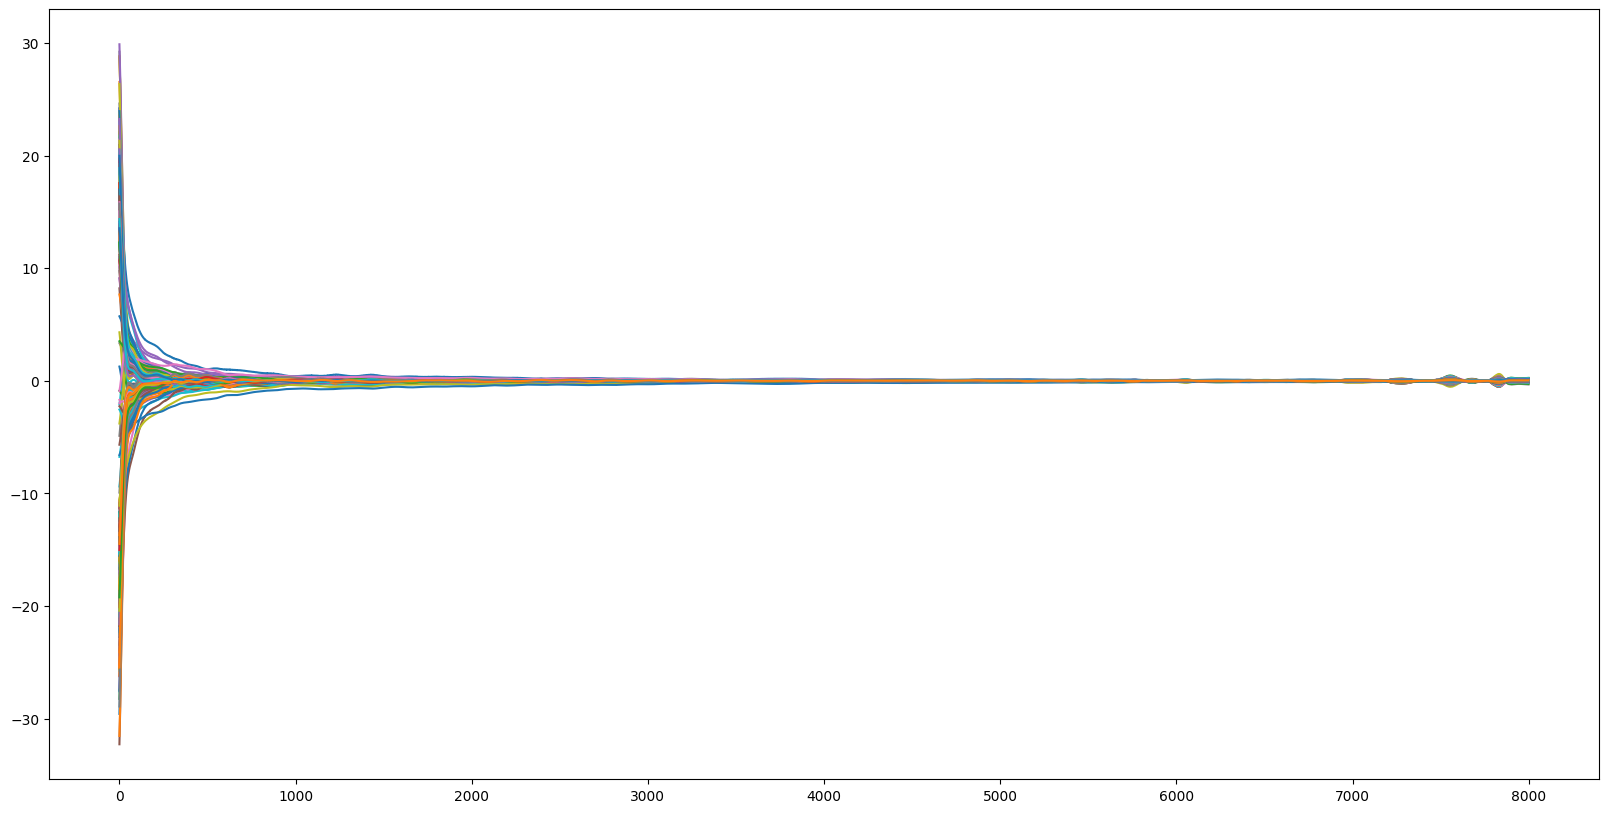

In [88]:
filter = mixers[-1].filter(8198)
fig = plt.figure(figsize=(20,10))
for z in range(512):
    plt.plot(filter[z,:8000].detach().cpu().numpy(),alpha=1)


In [79]:
fig, axs = plt.subplots(7, 4, figsize=(20, 20))

for i in range(4):
    for j in range(7):
        filter = mixers[4*i+j].filter(8198)
        for z in range(32):
            axs[j, i].plot(filter[z].detach().cpu().numpy())
            axs[j, i].set_title(f'layer {4*i+j}')